1. 데이터셋 불러와서 학습 준비

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
#한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

#마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [9]:
df = pd.read_csv('data/fetch_california_housing.csv')

df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [10]:
# X, y 분리
X = df.drop(columns = 'MedHouseVal')
y = df['MedHouseVal']

print(X.shape, y.shape) # (20640, 8) # (20640, 1)

(20640, 8) (20640,)


In [11]:
from sklearn.model_selection import train_test_split

# 학습데이터와 테스트 데이터 분리 (학습80%, 테스트20%, random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

print(len(X_train),len(X_test),len(y_train),len(y_test))

16512 4128 16512 4128


In [ ]:
#StandardScaler 정규화 (학습데이터는 학습/변환, 테스트데이터는 변환)

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)


ndarray 형태인 X_train_scaled를 DataFrame 형식으로 재구성

In [15]:
# 스케일링 된 데이터 DataFrame 형태로 유지
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns = X_train.columns,  # 기존 컬럼명
    index = X_train.index       # 기존 인덱스
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns = X_test.columns,
    index = X_test.index
)

In [16]:
X_train_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551
...,...,...,...,...,...,...,...,...
11284,1.307215,0.507194,0.290620,-0.393391,-0.675847,-0.005588,-0.872016,0.808883
11964,-0.436266,0.348490,0.600411,0.398898,0.287195,0.069722,-0.759688,1.073144
5390,-0.496973,0.586545,-0.606759,-0.039216,0.289833,0.020306,-0.755007,0.599469
860,0.965450,-1.079841,0.402175,-0.066265,0.308303,0.007076,0.906510,-1.185540


In [17]:
X_test_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,-1.155085,-0.286324,-0.520686,-0.171746,-0.030301,0.067408,0.195100,0.285347
3024,-0.708659,0.110435,-0.165815,0.223472,0.121851,-0.036030,-0.235491,0.060975
15663,-0.210402,1.856173,-0.610765,0.205892,-0.102419,-0.149989,1.009478,-1.424870
20484,0.975113,-0.921138,0.305115,-0.176552,0.244979,0.030011,-0.637999,0.429943
9814,-0.081794,0.427842,0.024193,-0.158465,-0.319653,-0.052971,0.457199,-1.170581
...,...,...,...,...,...,...,...,...
15362,0.380334,-1.000489,0.656380,-0.069975,-0.066360,-0.009330,-1.068590,1.177851
16623,-0.606098,-0.048268,0.291827,0.369465,0.196607,-0.065340,-0.132523,-0.622115
18086,2.809024,-0.286324,0.755012,-0.345109,0.139441,-0.026469,0.780141,-1.230414
2144,-0.575430,0.586545,-0.061243,-0.262147,-0.175417,-0.043905,0.527404,-0.088607


PyTorch를 사용한 모델 학습

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [19]:
X_train_tensor = torch.from_numpy(X_train_scaled.to_numpy()).float()     # train 데이터 FloatTensor 변환
X_test_tensor = torch.from_numpy(X_test_scaled.to_numpy()).float()       # test 데이터 FloatTensor 변환

y_train_tensor = torch.from_numpy(y_train.values).float().reshape(-1, 1) # (샘플 수, 1) 형태로 변환시켜 학습에 사용
y_test_tensor = torch.from_numpy(y_test.values).float().reshape(-1,1)    # (샘플 수, 1) 형태로 변환시켜 테스트에 사용

print(X_train_tensor.size(), X_test_tensor.size(), y_train_tensor.size(), y_test_tensor.size())


torch.Size([16512, 8]) torch.Size([4128, 8]) torch.Size([16512, 1]) torch.Size([4128, 1])


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32580\2839944122.py:1: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  X_train_tensor = torch.from_numpy(X_train_scaled.to_numpy()).float()     # train 데이터 FloatTensor 변환


In [20]:
# 하이퍼 파라미터 설정
n_epochs = 5000        # 반복횟수
learning_rate = 1e-3   # 학습률
print_interval = 500   # 로그 출력 간격


In [21]:
X_train_tensor.size()

torch.Size([16512, 8])

In [23]:
y_train_tensor.size()

torch.Size([16512, 1])

3. 모델 구축
- nn.Sequential을 사용
- 입력을 받아 64차원 노드 은닉층
- 64개 노드 -> 64 은닉층
- 64개 노드 -> 32개 은닉층
- 32개 노드 -> 출력층

- 활성화함수는 ReLU()

In [28]:
# 모델 구축
model = nn.Sequential(
    nn.Linear(X_train_tensor.size(-1), 64),  # 입력층 -> 은닉층
    nn.ReLU(),

    nn.Linear(64,64),                        # 은닉층 -> 은닉층
    nn.ReLU(),

    nn.Linear(64,32),                        # 은닉층 -> 은닉층
    nn.ReLU(),

    # 출력층
    nn.Linear(32, y_train_tensor.size(-1))   # 회귀는 출력차원 1
)

In [29]:
optimizer = optim.Adam(
    model.parameters(), # 학습대상 : 가중치, 편향 파라미터
    lr = learning_rate  # 학습률
)

In [30]:
torch.cuda.is_available()

False

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU 사용가능시 cuda, 불가시 cpu
model = model.to(device)                                              # 모델 이동

In [32]:
# CPU / GPU로 데이터 이동
X_train = X_train_tensor.to(device) 
y_train = y_train_tensor.to(device)
X_test = X_test_tensor.to(device)
y_test = y_test_tensor.to(device)

In [ ]:
# 학습 루프
for epoch in range(n_epochs):
    model.train()                          # 학습 모드(dropout, batchnorm 활성화 : 과적합 방지기법)

    y_hat = model(X_train)                 # 순전파 : 모델 예측값 개선
    loss = F.mse_loss(y_hat, y_train)      # 평균제곱오차(MSE) 손실 계산

    optimizer.zero_grad()                  #기존 루프의 기울기 초기화
    loss.backward()                        # 역전파 : 손실을 기준으로 기울기 재계산

    optimizer.step()                       # 파라미터 업데이트


    # 500번마다 학습손실 출력
    if (epoch + 1) % print_interval == 0:
        print(f"Epoch {epoch + 1}의 Train Loss : {loss.item():.4e}")  # Tensor -> python float 형태로 확인


# 테스트
model.eval() # 평가 모드 (dropout, batchnorm 비활성화)
with torch.no_grad(): # 기울기 계산 비활성화
    y_pred_test = model(X_test) # 테스트 데이터 예측
    test_loss = F.mse_loss(y_pred_test, y_test) # 테스트 손실 계산
print(f"Test MSE : {test_loss.item():.4e}")     # 테스트 MSE 출력


Epoch 500의 Train Loss : 2.9558e-01
Epoch 1000의 Train Loss : 2.4549e-01
Epoch 1500의 Train Loss : 2.2898e-01
Epoch 2000의 Train Loss : 2.1869e-01
Epoch 2500의 Train Loss : 2.1012e-01
Epoch 3000의 Train Loss : 2.0415e-01
Epoch 3500의 Train Loss : 1.9875e-01
Epoch 4000의 Train Loss : 1.9190e-01
Epoch 4500의 Train Loss : 1.8758e-01
Epoch 5000의 Train Loss : 1.8366e-01
Test MSE : 2.9277e-01


4. 시각화 결과 확인

<function matplotlib.pyplot.show(close=None, block=None)>

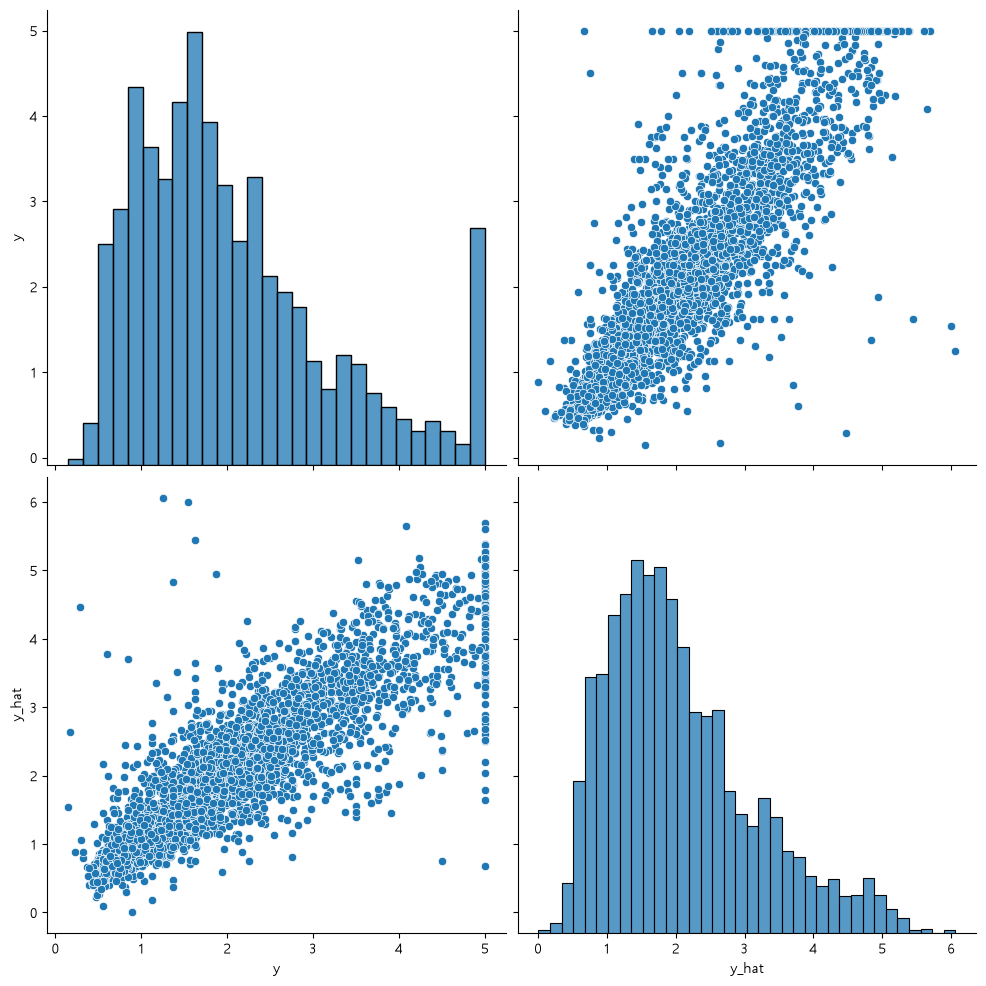

In [ ]:
# GPU에서 학습한 모델, 데이터들을 다시 CPU로 가져와서 시각화

model.eval()
with torch.no_grad(): # 추론시
    y_pred = model(X_test).cpu().numpy().reshape(-1) # 예측값을 CPU -> Numpy -> 1차원 배열로 변환 
    y_true = y_test.cpu().numpy().reshape(-1)        # 정답값을 CPU -> Numpy -> 1차원 배열로 변환

df_result = pd.DataFrame({
    "y":y_true,
    "y_hat": y_pred
})    

sns.pairplot(df_result, height = 5)
plt.show